# CoX-LMM: Concept eXplainability for Large Multimodal Models

This notebook implements the CoX-LMM framework, a novel dictionary-learning approach to interpret the internal representations of Large Multimodal Models (LMMs). While traditional explainability often focuses on CNNs or text-only LLMs, this method extracts "multimodal concepts" that are simultaneously grounded in both vision and text.

First, we will set up our environment and import the necessary libraries. We rely on `transformers` for the LMM, and `scikit-learn` to handle the dictionary learning process.

In [1]:
!pip install -q bitsandbytes accelerate

In [2]:
import torch
import torchvision
import os
import numpy as np
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from sklearn.decomposition import DictionaryLearning
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

Download and Extract COCO 2017 Validation Data

In [3]:
!mkdir -p ./data/annotations

# Download the validation images and the annotations
!wget -nc http://images.cocodataset.org/zips/val2017.zip -P ./data
!wget -nc http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P ./data

# Unzip the images and annotations quietly (-q)
!unzip -q -n ./data/val2017.zip -d ./data
!unzip -q -n ./data/annotations_trainval2017.zip -d ./data

# Clean up the zip files to save disk space
!rm ./data/val2017.zip
!rm ./data/annotations_trainval2017.zip

print("COCO dataset download and extraction complete!")

--2026-03-18 17:51:05--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.7.166, 16.15.186.173, 16.15.178.127, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.7.166|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘./data/val2017.zip’

val2017.zip         100%[===================>] 777.80M  53.8MB/s    in 15s     

2026-03-18 17:51:20 (51.6 MB/s) - ‘./data/val2017.zip’ saved [815585330/815585330]

--2026-03-18 17:51:20--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.53.81, 16.15.183.112, 3.5.25.122, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.53.81|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘./data/annotations_trainval2017.zip’

annotatio

In [4]:
coco_val = torchvision.datasets.CocoCaptions(
    root='./data/val2017',
    annFile='./data/annotations/captions_val2017.json'
)

target_token = "dog"
image_paths = []

for i in range(len(coco_val)):
    img, captions = coco_val[i]
    combined_captions = " ".join(captions).lower()
    if target_token in combined_captions.split():
        img_id = coco_val.coco.getImgIds()[i]
        file_name = coco_val.coco.loadImgs(img_id)[0]['file_name']
        image_paths.append(os.path.join('./data/val2017', file_name))

print(f"Found {len(image_paths)} images containing a {target_token}.")

loading annotations into memory...
Done (t=0.38s)
creating index...
index created!
Found 176 images containing a dog.


## Step 1: Initialize the Model and Target Token

We need to select a specific target token (e.g., 'dog') to analyze. The framework investigates how the LMM internally represents this specific concept across various images.

We will load the LLaVA model, which the authors explicitly tested to prove the framework's generalizability. Following the paper's default hyperparameters, we will extract $K=20$ concepts from a deep layer (layer $L=31$), and set the sparsity penalty $\lambda=1$.

In [5]:
model_id = "llava-hf/llava-1.5-7b-hf"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True        )

processor = AutoProcessor.from_pretrained(model_id)

# Load the model with the config
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto"
)

target_token_id = processor.tokenizer.encode(target_token, add_special_tokens=False)[0]

# Hyperparameters from the paper
K = 20
L = 31
lam = 1.0

print(f"Model loaded! VRAM used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded! VRAM used: 3.78 GB


## Step 2: Extracting Internal Representations

To understand the target token, we must extract its internal "residual stream" representation, denoted as $h_{(L)}^p$, from our chosen deep layer $L$. We do this only at the sequence position $p$ where the target token is predicted by the model.

We pass a dataset of images containing our target object through the model, capturing these representations to build a matrix $Z \in \mathbb{R}^{B \times M}$, where $B$ is the hidden dimension size and $M$ is the number of valid image samples.

In [7]:
Z_list = []
valid_image_paths = []

for img_path in tqdm(image_paths):
    try:
        # Ensure image is RGB
        image = Image.open(img_path).convert("RGB")
        prompt = "USER: <image>\nDescribe the image. ASSISTANT:"
        inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

        # Forward pass to get hidden states
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=50,
                return_dict_in_generate=True,
                output_hidden_states=True
            )

        input_length = inputs.input_ids.shape[1]
        generated_tokens = outputs.sequences[0, input_length:]
        token_positions = (generated_tokens == target_token_id).nonzero(as_tuple=True)[0]

        if len(token_positions) > 0:
            # Get the first occurrence position in the generated sequence
            gen_pos = token_positions[0].item()

            # Extract representation from Layer L using the generation step
            rep = outputs.hidden_states[gen_pos][L][0, -1, :].float().cpu().numpy()
            Z_list.append(rep)
            valid_image_paths.append(img_path)

    except Exception as e:
        print(f"Skipping {img_path} due to error: {e}")

    # Free up memory to prevent CUDA Out of Memory errors
    if 'inputs' in locals(): del inputs
    if 'outputs' in locals(): del outputs
    torch.cuda.empty_cache()

# Build Representation Matrix Z: Shape (B, M)
Z = np.stack(Z_list, axis=1)
print(f"Matrix Z shape: {Z.shape}")

100%|██████████| 176/176 [13:02<00:00,  4.44s/it]

Matrix Z shape: (4096, 6)


## Step 3: Decomposing the Representation Matrix

We linearly decompose our representation matrix $Z \approx UV$ to discover the underlying concepts.
* **$U \in \mathbb{R}^{B \times K}$**: The learned concept dictionary (our basis vectors)
* **$V \in \mathbb{R}^{K \times M}$**: The activations/coefficients of these concepts for each sample.

Because the residual stream representations in $Z$ can contain negative values, standard Non-negative Matrix Factorization (NMF) will not work. Instead, the authors use **Semi-NMF**, which allows mixed values in $Z$ and $U$, but enforces non-negativity and sparsity on the activations $V$.

The optimization problem is defined as:
$$U^*, V^* = \text{arg min}_{U,V} ||Z - UV||_F^2 + \lambda ||V||_1$$
subject to $V \ge 0$ and $||u_k||_2 \le 1$ for all $k$.

In [14]:
# We transpose Z for sklearn, which expects (n_samples, n_features)
Z_t = Z.T

# Initialize Semi-NMF via DictionaryLearning with positive_code=True
dict_learner = DictionaryLearning(
    n_components=K,
    alpha=lam,
    positive_code=True,
    fit_algorithm='cd',
    transform_algorithm='lasso_cd',
    random_state=42,
    transform_max_iter=10_000
)

V_t = dict_learner.fit_transform(Z_t)
U_t = dict_learner.components_

# Transpose back to match paper's notation
U = U_t.T
V = V_t.T

## Step 4A: Visual Grounding of Concepts

Now that we have extracted $K$ concept vectors, what do they actually mean? We evaluate their semantic structure by grounding them visually.

For each concept $u_k$, we find the Maximum Activating Samples (MAS). These are the input images from our dataset that yield the highest activation scores in our coefficient matrix $V$.We will select the top 5 images for each concept.

In [15]:
N_MAS = 5
visual_grounding = {}

for k in range(K):
    # Get activations for concept k across all samples M
    activations_k = V[k, :]

    # Get indices of top N_MAS images
    top_indices = np.argsort(activations_k)[-N_MAS:][::-1]

    visual_grounding[k] = [valid_image_paths[idx] for idx in top_indices]

## Step 4B: Textual Grounding of Concepts

To prove these concepts are truly *multimodal*, we must also ground them in text.

Because our concept vectors $u_k$ live in the token representation space of the Language Model, we can project them directly into the model's vocabulary space using the unembedding matrix $W_U$. We then extract the most probable tokens to create a set of grounded words, $T_k$, which describe the visual features the concept has captured.

In [16]:
text_grounding = {}

# Get the unembedding weights from the model (lm_head)
W_U = model.lm_head.weight.detach().cpu().numpy()

for k in range(K):
    concept_vector = U[:, k]

    # Map u_k to vocabulary space: W_U * u_k
    logits = np.dot(W_U, concept_vector)

    # Get top 15 token indices
    top_token_ids = np.argsort(logits)[-15:][::-1]

    # Decode to words
    decoded_words = [processor.tokenizer.decode([tid]).strip() for tid in top_token_ids]

    # Filter out words <= 3 chars
    filtered_words = [w for w in decoded_words if len(w) > 3]

    text_grounding[k] = filtered_words[:5]

## Step 5: Visualizing Multimodal Concepts

Finally, we bring the visual and textual grounding together to interpret what the LMM has learned.

For each of the extracted components, we will plot the 5 Maximum Activating Samples (the visual grounding). To the left of these images, we will display the top decoded words extracted from the language model's unembedding layer (the textual grounding).

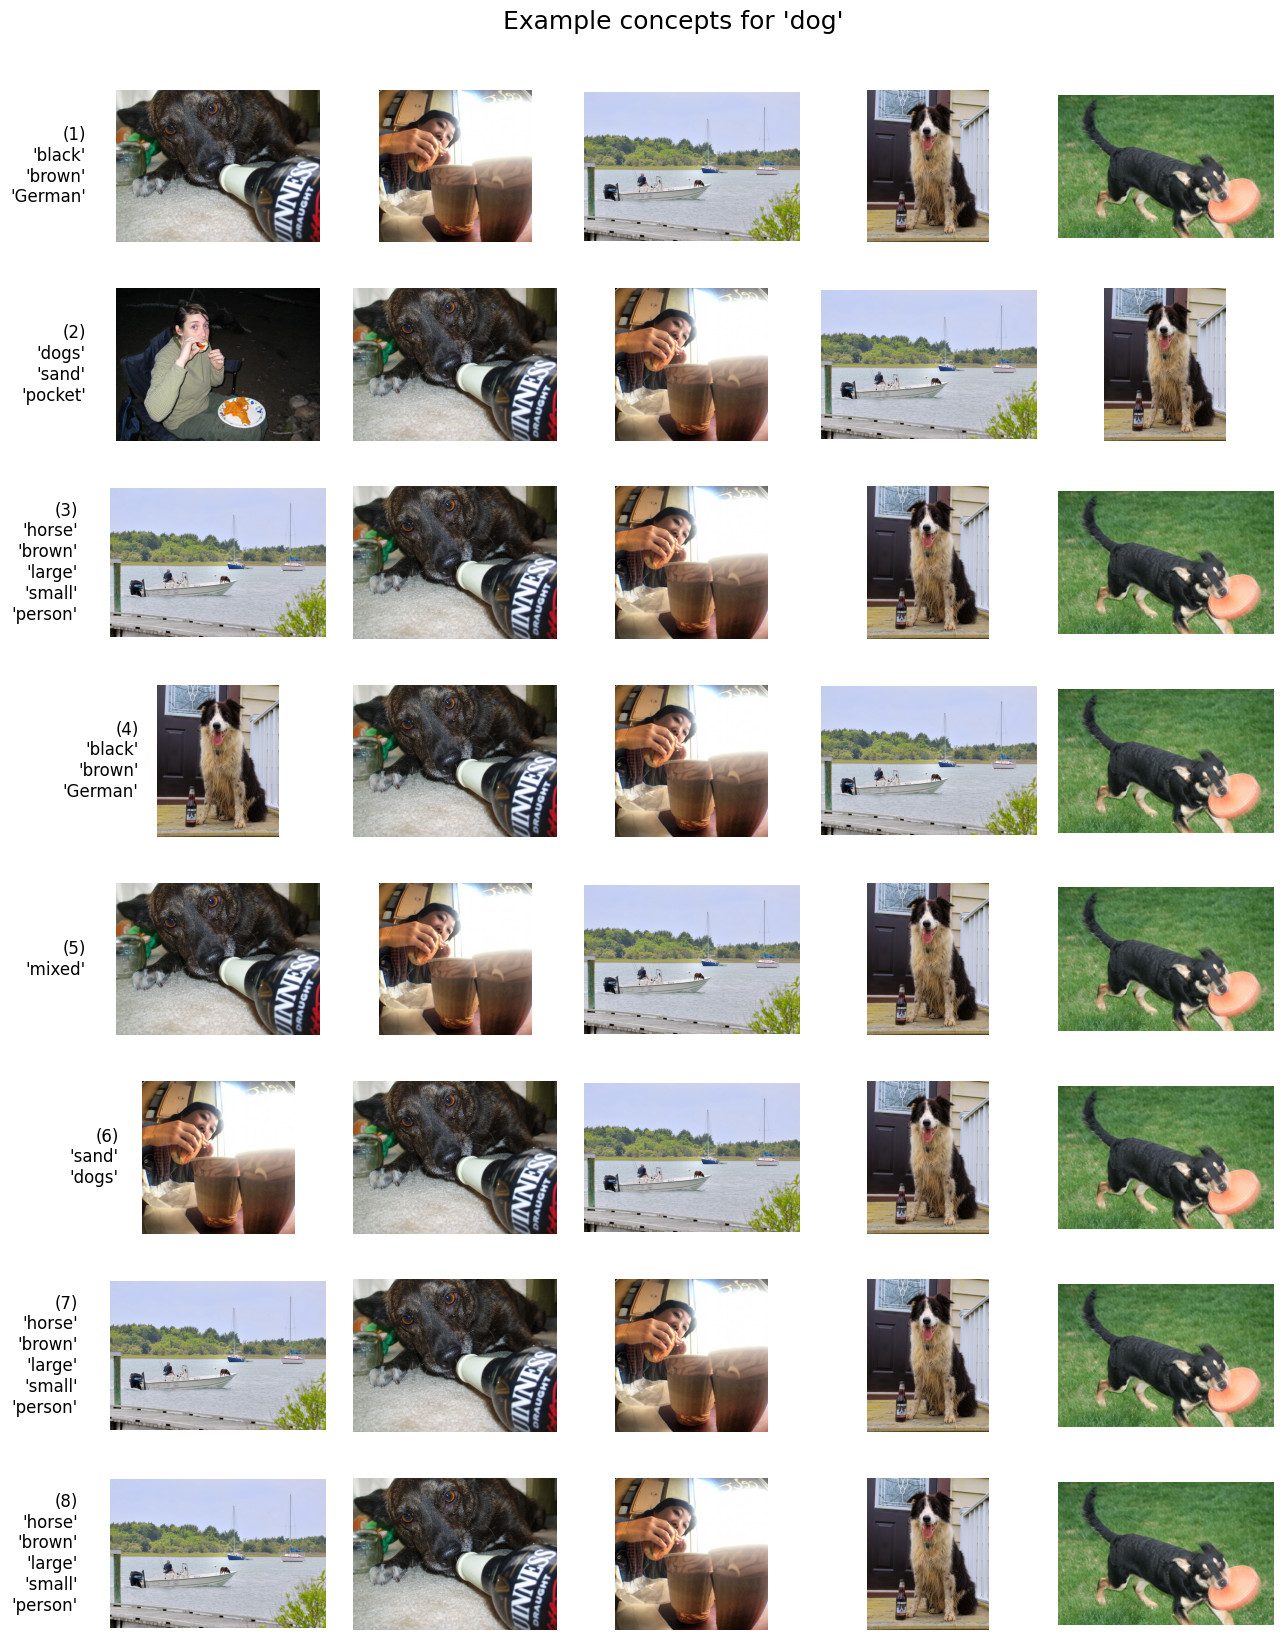

In [17]:
num_concepts_to_show = min(8, K)

fig, axes = plt.subplots(num_concepts_to_show, N_MAS, figsize=(15, 2.5 * num_concepts_to_show))
fig.subplots_adjust(wspace=0.1, hspace=0.3)

for k in range(num_concepts_to_show):
    # Fetch the textual grounding (top words) for concept k
    words = text_grounding.get(k, [])
    word_str = "\n".join([f"'{w}'" for w in words])

    # Fetch the visual grounding (image paths) for concept k
    img_paths = visual_grounding.get(k, [])

    for i in range(N_MAS):
        ax = axes[k, i]
        ax.axis('off')

        if i < len(img_paths):
            try:
                img = Image.open(img_paths[i]).convert("RGB")
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, "Image Error", ha='center', va='center')

        # Add the textual grounding to the left side of the very first image in the row
        if i == 0:
            ax.text(-0.15, 0.5, f"({k+1})\n{word_str}",
                    transform=ax.transAxes,
                    fontsize=12,
                    verticalalignment='center',
                    horizontalalignment='right')

plt.suptitle(f"Example concepts for '{target_token}'", fontsize=18, y=0.92)
plt.show()

## Conclusion and Result Analysis

We have successfully implemented the CoX-LMM framework and extracted multimodal concepts for the target token **'dog'**. Looking at the generated grid, we can observe several fascinating behaviors about how the LLaVA model internally represents this token:

* **Polysemanticity ("Hot Dog" vs. "Dog"):** Notice how almost every concept highly activates for an image of a person eating! This perfectly replicates a key finding from the paper: the LMM often superimposes the semantic concept of the animal "dog" with the food "hot dog".
* **Color and Breed Groupings:** In Concepts 1 and 4, the textual grounding decodes to words like 'black', 'brown', and 'German'. This indicates the model is successfully dedicating internal dimensions to specific physical traits of dogs.
* **The "Small Sample Size" Effect:** You will likely notice a high degree of overlap between the concepts. For instance, Concepts 3, 7, and 8 decode to the exact same words ('horse', 'brown', 'large', 'small', 'person') and trigger the exact same images. Furthermore, the same 5 or 6 images dominate the entire grid.

**Why are the concepts entangled?** This high overlap is a direct result of running the Semi-NMF algorithm on a very small slice of data (e.g., $N=50$ images). Dictionary learning algorithms require a massive diversity of input samples (a large matrix $Z$) to separate the representation space into $K=20$ distinct, disentangled basis vectors. With only a few dozen images, the algorithm is forced to aggressively reuse the same highest-activating samples across multiple concepts.

**Next Steps:**
To achieve the beautifully disentangled, highly specific concepts shown in the original paper (e.g., one row for *just* puppies, one row for *just* fluffy dogs), we need to scale up. Removing the `[:50]` slice constraint and running the extraction over a few thousand images from the COCO dataset will provide the Semi-NMF algorithm with the diversity it needs to truly isolate the distinct features of a 'dog'.